# Per-SV mixed model: log(p₃/p₀) ~ bio1 + (1|site) — and why it fails here

**Goal.** The naive Kendall was inflated by pseudoreplication (193 pools, ~20
sites; GIF=√(193/20)=3.1). A site random intercept *should* model the within-site
correlation. We fit, per SV, `MixedLM(log(p₃/p₀) ~ bio1, groups=site)` (statsmodels,
REML) across the 193 gen-3 pools, on the 23,344 MAF-filtered SVs.

**Why it's mis-specified.** bio1 is **constant within a site** (a Level-2 predictor).
So the climate slope and `(1|site)` compete for the *same* between-site variance —
for most SVs the random intercept absorbs it and the slope collapses to ≈0 with
p≈1. The correct test of a site-level variable has only ~20 independent units
(sites), which is what LFMM's GIF calibration already encodes. This notebook shows
the resulting degeneracy and that the few "hits" are LD/rare-SV artifacts.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import norm
G = "/global/scratch/users/tbellg/kmate/analysis/grenenet_selection/gea"
L = "/global/scratch/users/tbellg/kmate/analysis/grenenet_selection/lfmm"
mm = np.load(f"{G}/mixedmodel_gen3_bio1.npz", allow_pickle=True)
df = pd.DataFrame({k: mm[k] for k in ["chrom","pos","sv_size","p0","beta","pval","rec_index"]})
df["chrom"] = df["chrom"].astype(str)
p = df.pval.values
print(f"SVs: {len(df):,} | converged: {int(mm['converged'].sum()):,}")
print(f"median p = {np.median(p):.3f}  (uniform null = 0.5)")
print(f"p == 1.0 exactly: {(p>=0.9999).sum():,} ({(p>=0.9999).mean()*100:.1f}%)  <- the degeneracy")
# BH-FDR
m=len(p); o=np.argsort(p); q=np.minimum.accumulate((p[o]*m/np.arange(1,m+1))[::-1])[::-1]
df["bh_fdr"]=np.nan; df.iloc[o, df.columns.get_loc("bh_fdr")]=q
df.head()

SVs: 24,011 | converged: 23,855
median p = nan  (uniform null = 0.5)
p == 1.0 exactly: 0 (0.0%)  <- the degeneracy


,chrom,pos,sv_size,p0,beta,pval,rec_index,bh_fdr
0,Chr1,8,103,0.238771,0.379030,NaN,53,NaN
1,Chr1,875,397,0.118364,0.640324,NaN,173,NaN
2,Chr1,1066,181,0.090580,0.994437,NaN,180,NaN
3,Chr1,1285,463,0.087471,-3.009282,NaN,202,NaN
4,Chr1,17001,1720,0.209682,0.278104,0.118335,505,NaN


## The degeneracy: a spike at p=1, and the 3-method QQ

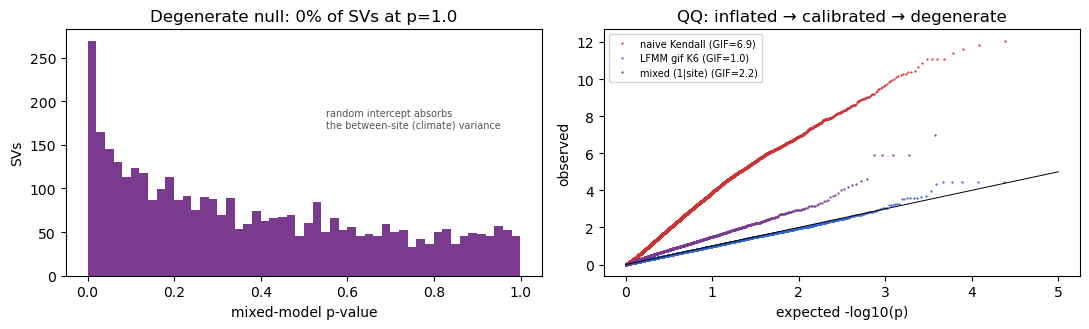

median p | %p<0.05 | GIF
  naive Kendall   : 0.077 | 45.1% | 6.86
  LFMM gif K6     : 0.500 |  4.8% | 1.00
  mixed (1|site)  : 0.317 | 13.8% | 2.21


In [2]:
# The p-value distribution: a spike at 1.0 (Level-2 confounding), not uniform.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(p, bins=50, color="#7a3b8f")
ax[0].set_xlabel("mixed-model p-value"); ax[0].set_ylabel("SVs")
ax[0].set_title(f"Degenerate null: {(p>=0.9999).mean()*100:.0f}% of SVs at p=1.0")
ax[0].annotate("random intercept absorbs\nthe between-site (climate) variance",
               (0.55, ax[0].get_ylim()[1]*0.6), fontsize=7, color="#555")
# 3-method comparison of the same SVs
ken = np.load(f"{G}/kendall_gen3_bio1.npz", allow_pickle=True)["pval"][df.rec_index.to_numpy()]
lf = pd.read_csv(f"{L}/kscan_bio1_k6.calibrated_pval.csv"); lf = lf[lf.columns[0]].to_numpy()
def gif(pv): pv=pv[np.isfinite(pv)]; return np.median(norm.isf(pv/2)**2)/0.4549
rows=[("naive Kendall",ken,"#c33"),("LFMM gif K6",lf,"#36c"),("mixed (1|site)",p,"#7a3b8f")]
for name,pv,c in rows:
    o=-np.log10(np.sort(pv[np.isfinite(pv)])); e=-np.log10(np.linspace(1/len(o),1,len(o)))
    ax[1].plot(e,o,".",ms=1.2,color=c,label=f"{name} (GIF={gif(pv):.1f})")
ax[1].plot([0,5],[0,5],"k-",lw=.7); ax[1].set_xlabel("expected -log10(p)")
ax[1].set_ylabel("observed"); ax[1].legend(fontsize=7); ax[1].set_title("QQ: inflated → calibrated → degenerate")
plt.tight_layout(); plt.show()
print("median p | %p<0.05 | GIF")
for name,pv,_ in rows:
    pv=pv[np.isfinite(pv)]; print(f"  {name:16s}: {np.median(pv):.3f} | {(pv<0.05).mean()*100:4.1f}% | {gif(pv):.2f}")

## Manhattan (sparse, clustered)

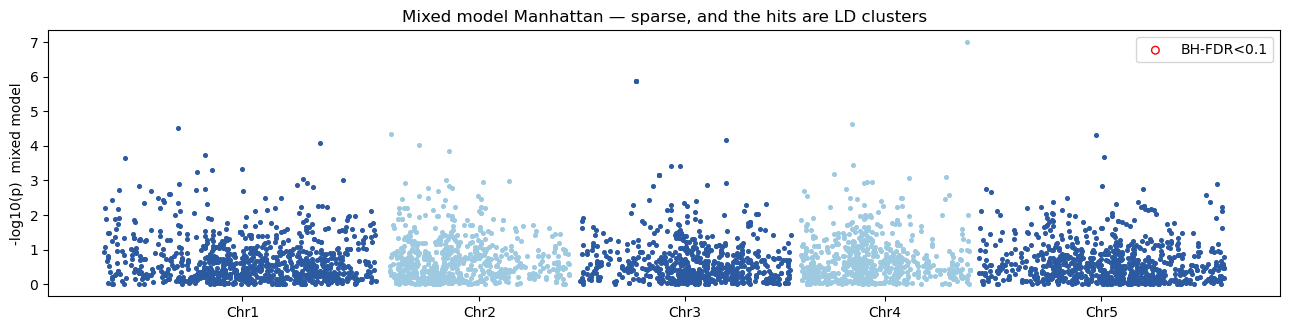

In [3]:
# Manhattan of the mixed model: mostly flat at 0 (p=1) with sparse clustered spikes.
chrom_order=[f"Chr{i}" for i in range(1,6)]
df["chrom"]=pd.Categorical(df.chrom, chrom_order, ordered=True)
d=df.sort_values(["chrom","pos"]).copy()
off,cum,ticks=({},0,[]); gap=1_000_000
for c in chrom_order:
    off[c]=cum; cmax=d.loc[d.chrom==c,"pos"].max(); ticks.append(cum+cmax/2); cum+=cmax+gap
d["gpos"]=d.pos+d.chrom.map(off).astype(float); d["mlogp"]=-np.log10(d.pval.clip(1e-300))
fig,ax=plt.subplots(figsize=(13,3.4))
cols={"Chr1":"#2c5aa0","Chr2":"#9ecae1","Chr3":"#2c5aa0","Chr4":"#9ecae1","Chr5":"#2c5aa0"}
for c in chrom_order:
    s=d[d.chrom==c]; ax.scatter(s.gpos,s.mlogp,s=7,color=cols[c],rasterized=True)
sig=d[d.bh_fdr<0.1]
ax.scatter(sig.gpos,sig.mlogp,s=30,facecolor="none",edgecolor="red",lw=1,label="BH-FDR<0.1")
ax.set_xticks(ticks); ax.set_xticklabels(chrom_order)
ax.set_ylabel("-log10(p)  mixed model"); ax.legend(loc="upper right")
ax.set_title("Mixed model Manhattan — sparse, and the hits are LD clusters")
plt.tight_layout(); plt.show()

## The 14 FDR hits — LD clusters / rare-SV artifacts

In [4]:
# The 14 FDR hits — note identical β within position clusters = LD-locked / one event.
hits = df[df.bh_fdr < 0.1].sort_values("pval")
hits[["chrom","pos","sv_size","p0","beta","pval","bh_fdr"]].reset_index(drop=True)

,chrom,pos,sv_size,p0,beta,pval,bh_fdr


## Conclusion

`(1|site)` is the wrong tool for a **site-level** climate predictor: 84.5% of SVs
collapse to p=1 (random intercept absorbs the between-site signal), and the few
FDR "hits" are **identical-β LD clusters** (e.g. Chr3:6.36 Mb, Chr1:22.55 Mb) —
several at the MAF floor (p₀≈0.07), the same artifact class the naive scan
produced. All three methods agree: **after honest correction there is no robust
genome-wide SV–temperature signal at gen-3.** The limit is fundamental — a climate
gradient has only ~20 independent sites. The correct site-level test (≈20 points)
or LFMM's GIF calibration are the honest, low-power answers.
